In this notebook, we explore some supervised learning models to predict the outcome variable $\texttt{VTE}$ using the fully imputed and pre‑processed dataset $\texttt{df\_ready}$ ($\texttt{synthetic\_clinical\_data}$ for reproductiblity), which was generated in the previous step after handling missing values, preserving clinically meaningful correlations between variables, and ensuring all features are consistent. The models tried here are:
+ Random forest
+ Logistic regression
+ Gradient boosting

The accuracy results from the predictions (ROC-AUC and PR-AUC) will be saved on $\texttt{results/4.synthetic\_supervised\_models}$. A summary table is provided at the end of the notebook, reporting the mean ROC‑AUC, PR‑AUC, and accuracy values. These averages are computed across multiple runs using different random states.

## Load the data

From $\texttt{df\_ready}$.

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import os

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns

path_data = "dataframes/synthetic_clinical_data.csv"
df = pd.read_csv(path_data)

In [2]:
# Check the class imbalance

vte_counts = df["VTE"].value_counts(dropna=False)
vte_percent = df["VTE"].value_counts(normalize=True, dropna=False) * 100

vte_table = pd.DataFrame({
    "Count": vte_counts,
    "Percent": vte_percent.round(2)
})

print(vte_table)

     Count  Percent
VTE                
0.0    289    73.91
1.0    102    26.09


### Split training and testing

Because there are no nan values, and only 24.3% of patients had $\texttt{VTE}$, the class is, in fact, imbalanced. For that reason, when splitting between training and test sets, they are going to be stratified.

In [3]:
random_state=42
test_size=0.9

X = df.drop(columns=["VTE"])

y = df["VTE"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=random_state, stratify=y
)

In [4]:
# Check % of train and test sets

print("\n=== TRAIN SET ===")
vte_counts_train = y_train.value_counts(dropna=False)
vte_percent_train = y_train.value_counts(normalize=True, dropna=False) * 100

vte_table_train = pd.DataFrame({
    "Count": vte_counts_train,
    "Percent": vte_percent_train.round(2)
})

print(vte_table_train)
print("NaNs:", y_train.isna().sum())

print("\n=== TEST SET ===")
vte_counts_test = y_test.value_counts(dropna=False)
vte_percent_test = y_test.value_counts(normalize=True, dropna=False) * 100

vte_table_test = pd.DataFrame({
    "Count": vte_counts_test,
    "Percent": vte_percent_test.round(2)
})

print(vte_table_test)
print("NaNs:", y_test.isna().sum())


=== TRAIN SET ===
     Count  Percent
VTE                
0.0     29    74.36
1.0     10    25.64
NaNs: 0

=== TEST SET ===
     Count  Percent
VTE                
0.0    260    73.86
1.0     92    26.14
NaNs: 0


### Create the $\texttt{.csv}$ file

Once the training and test sets are well-defined, we can continue with trying supervised machine learning models. For that, we'll save all the accuracy results on a $\texttt{.csv}$ file, for posterior analysis.

In [5]:
results_path = "results/4.synthetic_supervised_ml.csv"

# Check if file exists
if not os.path.exists(results_path):
    print("File not found. Creating new results file...")

    df_results = pd.DataFrame(columns=[
        "model",
        "random_state",
        "test_size",
        "ROC-AUC",
        "PR-AUC",
        "Accuracy"
    ])

    df_results.to_csv(results_path, index=False)
else:
    print("Results file already exists.")
    df_results = pd.read_csv(results_path)

df_results.head()

Results file already exists.


,model,random_state,test_size,ROC-AUC,PR-AUC,Accuracy
0,Random Forest,0,0.2,0.498768,0.358669,0.746835
1,Logistic Regression,0,0.2,0.409688,0.246739,0.506329
2,Gradient Boosting,0,0.2,0.495074,0.322740,0.708861
3,Random Forest,5,0.2,0.548440,0.308159,0.721519
4,Logistic Regression,5,0.2,0.558292,0.329812,0.518987


## Random forest

In [6]:
model = "Random Forest"

rf = RandomForestClassifier(
    n_estimators=101,
    max_depth=None,
    min_samples_split=2,
    random_state=random_state,
    class_weight="balanced"   # important for imbalanced VTE
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

In [7]:
roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)
acc = accuracy_score(y_test, y_pred)

print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)
print("Accuracy:", acc)

ROC-AUC: 0.4404891304347826
PR-AUC: 0.24953709989176096
Accuracy: 0.7386363636363636


<Figure size 600x500 with 0 Axes>

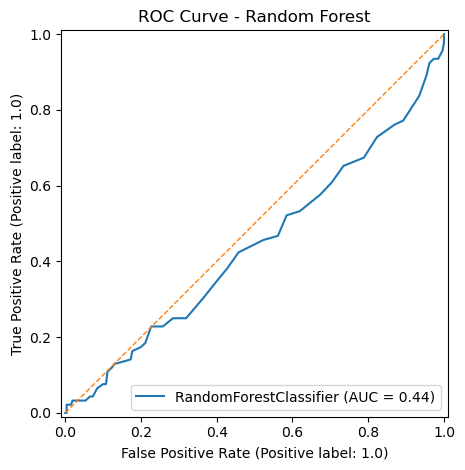

In [8]:
# --- ROC CURVE ---

plt.figure(figsize=(6,5))
RocCurveDisplay.from_estimator(rf, X_test, y_test)
plt.plot([0, 1], [0, 1], linestyle='--', linewidth=1)

plt.title("ROC Curve - Random Forest")
plt.tight_layout()
plt.show()

<Figure size 600x500 with 0 Axes>

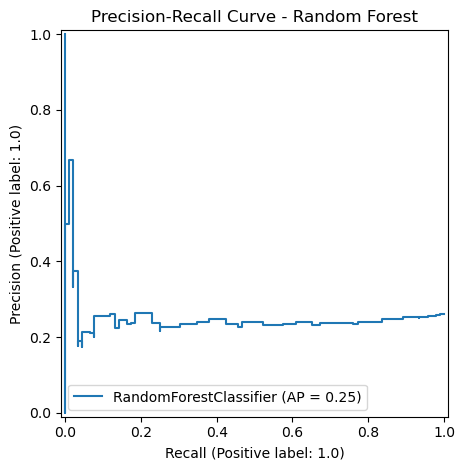

In [9]:
# --- PRECISION-RECALL CURVE ---

plt.figure(figsize=(6,5))
PrecisionRecallDisplay.from_estimator(rf, X_test, y_test)

plt.title("Precision-Recall Curve - Random Forest")
plt.tight_layout()
plt.show()

### Save results to the $\texttt{.csv}$

In [10]:
df_results.loc[len(df_results)] = [
    model,
    random_state,          # random_state already defined
    test_size,
    roc_auc,
    pr_auc,
    acc
]

df_results.to_csv(results_path, index=False)
df_results.tail()

,model,random_state,test_size,ROC-AUC,PR-AUC,Accuracy
47,Gradient Boosting,0,0.9,0.453177,0.226069,0.582386
48,Random Forest,5,0.9,0.487312,0.256050,0.721591
49,Logistic Regression,5,0.9,0.477174,0.244833,0.605114
50,Gradient Boosting,5,0.9,0.502947,0.260540,0.582386
51,Random Forest,42,0.9,0.440489,0.249537,0.738636


## Lineal Model (Logistic Regression)

In [11]:
model = "Logistic Regression"

logreg = LogisticRegression(
    max_iter=500,
    solver="lbfgs",
    random_state=random_state,
    class_weight="balanced"   # important for imbalanced VTE
)

# Fit
logreg.fit(X_train, y_train)

# Predictions
y_pred = logreg.predict(X_test)
y_proba = logreg.predict_proba(X_test)[:, 1]

In [12]:
roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)
acc = accuracy_score(y_test, y_pred)

print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)
print("Accuracy:", acc)

ROC-AUC: 0.49970735785953174
PR-AUC: 0.27550407187999476
Accuracy: 0.6477272727272727


<Figure size 600x500 with 0 Axes>

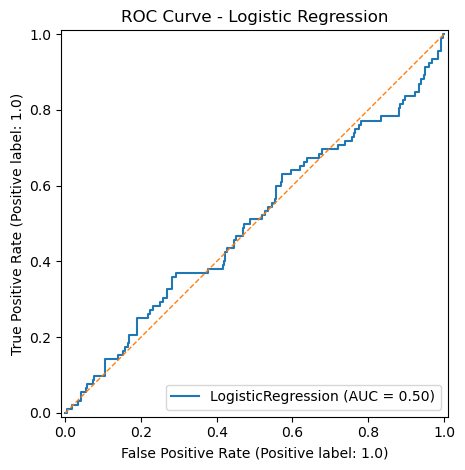

In [13]:
# --- ROC CURVE ---
plt.figure(figsize=(6,5))
RocCurveDisplay.from_estimator(logreg, X_test, y_test)
plt.plot([0, 1], [0, 1], linestyle='--', linewidth=1)
plt.title("ROC Curve - Logistic Regression")
plt.tight_layout()
plt.show()

<Figure size 600x500 with 0 Axes>

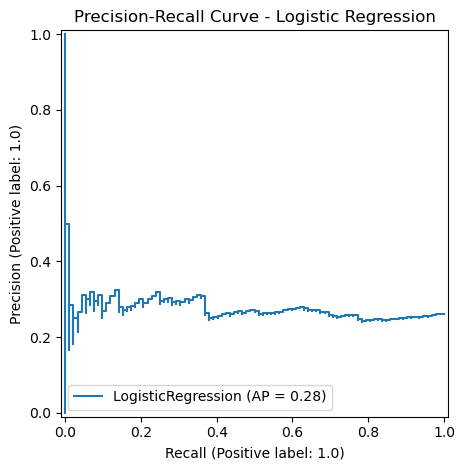

In [14]:
# --- PRECISION-RECALL CURVE ---
plt.figure(figsize=(6,5))
PrecisionRecallDisplay.from_estimator(logreg, X_test, y_test)
plt.title("Precision-Recall Curve - Logistic Regression")
plt.tight_layout()
plt.show()

### Save results to the $\texttt{.csv}$

In [15]:
df_results.loc[len(df_results)] = [
    model,
    random_state,
    test_size,
    roc_auc,
    pr_auc,
    acc
]

df_results.to_csv(results_path, index=False)
df_results.tail()

,model,random_state,test_size,ROC-AUC,PR-AUC,Accuracy
48,Random Forest,5,0.9,0.487312,0.256050,0.721591
49,Logistic Regression,5,0.9,0.477174,0.244833,0.605114
50,Gradient Boosting,5,0.9,0.502947,0.260540,0.582386
51,Random Forest,42,0.9,0.440489,0.249537,0.738636
52,Logistic Regression,42,0.9,0.499707,0.275504,0.647727


## Gradient boosting

In [16]:
model = "Gradient Boosting"

gb = GradientBoostingClassifier(
    random_state=random_state
)

# Fit
gb.fit(X_train, y_train)

# Predictions
y_pred = gb.predict(X_test)
y_proba = gb.predict_proba(X_test)[:, 1]

In [17]:
roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)
acc = accuracy_score(y_test, y_pred)

print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)
print("Accuracy:", acc)

ROC-AUC: 0.44397993311036793
PR-AUC: 0.2695287304704954
Accuracy: 0.6903409090909091


<Figure size 600x500 with 0 Axes>

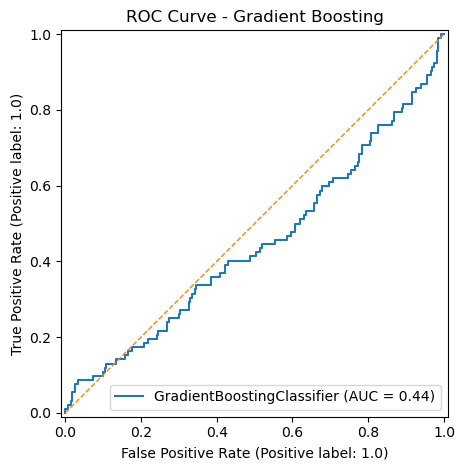

In [18]:
# --- ROC CURVE ---
plt.figure(figsize=(6,5))
RocCurveDisplay.from_estimator(gb, X_test, y_test)
plt.plot([0, 1], [0, 1], linestyle='--', linewidth=1)
plt.title("ROC Curve - Gradient Boosting")
plt.tight_layout()
plt.show()

<Figure size 600x500 with 0 Axes>

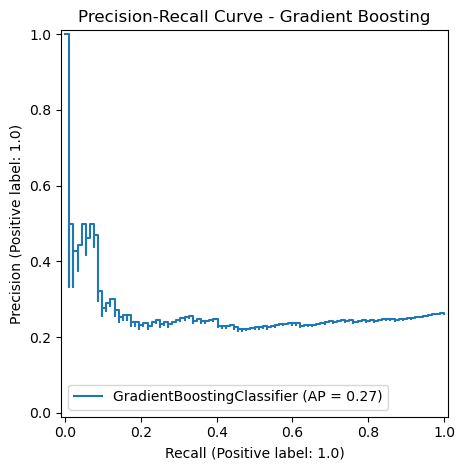

In [19]:
# --- PRECISION-RECALL CURVE ---
plt.figure(figsize=(6,5))
PrecisionRecallDisplay.from_estimator(gb, X_test, y_test)
plt.title("Precision-Recall Curve - Gradient Boosting")
plt.tight_layout()
plt.show()

### Save results to the $\texttt{.csv}$

In [20]:
df_results.loc[len(df_results)] = [
    model,
    random_state,
    test_size,
    roc_auc,
    pr_auc,
    acc
]

df_results.to_csv(results_path, index=False)
df_results.tail()

,model,random_state,test_size,ROC-AUC,PR-AUC,Accuracy
49,Logistic Regression,5,0.9,0.477174,0.244833,0.605114
50,Gradient Boosting,5,0.9,0.502947,0.260540,0.582386
51,Random Forest,42,0.9,0.440489,0.249537,0.738636
52,Logistic Regression,42,0.9,0.499707,0.275504,0.647727
53,Gradient Boosting,42,0.9,0.443980,0.269529,0.690341


## Summary of results of $\texttt{.csv}$

In [21]:
summary = (
    df_results
    .groupby(["model", "test_size"])[["ROC-AUC", "PR-AUC", "Accuracy"]]
    .mean()
    .reset_index()
)

summary

,model,test_size,ROC-AUC,PR-AUC,Accuracy
0,Gradient Boosting,0.20,0.530378,0.326359,0.687764
1,Gradient Boosting,0.33,0.503370,0.310915,0.710256
2,Gradient Boosting,0.50,0.494073,0.271851,0.685374
3,Gradient Boosting,0.66,0.530310,0.293673,0.676963
4,Gradient Boosting,0.75,0.493786,0.267431,0.668934
5,Gradient Boosting,0.90,0.466702,0.252046,0.618371
6,Logistic Regression,0.20,0.475643,0.282642,0.510549
7,Logistic Regression,0.33,0.490605,0.276378,0.517949
8,Logistic Regression,0.50,0.493036,0.265778,0.564626
9,Logistic Regression,0.66,0.536393,0.300623,0.577864


This results show us than a Random Forest classifies much better the data $\rightarrow$ our classifier for the contrastive model will be a Random forest. It's also observable that even a random forest struggles to predict $\texttt{VTE}$ when the train size is small.